# Neural Ray Tracing: Differentiable Rendering, Lighting, and Learned Inverse Models

This notebook extends the *Differentiable Ray Tracing from First Principles* lesson.
We keep the renderer in pure NumPy/Python (Peter Shirley style) while layering on three new capabilities:

1. **Optimizing lighting parameters** jointly with geometry.
2. **Stochastic pixel sampling** (mini-batches of rays) to scale optimization.
3. **Embedding the renderer inside a tiny neural network** that learns scene parameters via gradient-based inverse rendering.

## Learning Roadmap
- Re-use the ray, camera, and shading primitives from the base notebook.
- Promote the light into an optimizable parameter (direction + intensity).
- Introduce stochastic batches of pixels to mimic Monte Carlo training loops.
- Build a tiny neural network whose output feeds the renderer, illustrating differentiable pipelines without external autodiff frameworks.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

plt.rcParams['figure.dpi'] = 120
np.set_printoptions(precision=3, suppress=True)

In [11]:
@dataclass
class Ray:
    origin: np.ndarray
    direction: np.ndarray

def unit_vector(v: np.ndarray) -> np.ndarray:
    norm = np.linalg.norm(v)
    return v if norm < 1e-9 else v / norm

@dataclass
class Camera:
    width: int
    height: int
    origin: np.ndarray
    lower_left_corner: np.ndarray
    horizontal: np.ndarray
    vertical: np.ndarray

def make_camera(width: int = 96, height: int = 96, focal_length: float = 1.0) -> Camera:
    aspect = width / height
    viewport_height = 2.0
    viewport_width = aspect * viewport_height
    origin = np.array([0.0, 0.0, -1.0])
    horizontal = np.array([viewport_width, 0.0, 0.0])
    vertical = np.array([0.0, viewport_height, 0.0])
    lower_left_corner = origin + np.array([
        -viewport_width / 2,
        -viewport_height / 2,
        focal_length,
    ])
    return Camera(width, height, origin, lower_left_corner, horizontal, vertical)

def hit_sphere(center: np.ndarray, radius: float, ray: Ray) -> float:
    oc = ray.origin - center
    a = np.dot(ray.direction, ray.direction)
    b = 2.0 * np.dot(oc, ray.direction)
    c = np.dot(oc, oc) - radius ** 2
    discriminant = b ** 2 - 4 * a * c
    if discriminant < 0:
        return -1.0
    sq = np.sqrt(discriminant)
    t = (-b - sq) / (2 * a)
    if t > 0:
        return t
    t = (-b + sq) / (2 * a)
    return t if t > 0 else -1.0

def unpack_light(light_params: np.ndarray):
    raw_dir = light_params[:3]
    if np.linalg.norm(raw_dir) < 1e-6:
        raw_dir = np.array([0.0, 0.0, -1.0])
    direction = unit_vector(raw_dir)
    intensity = np.exp(light_params[3])  # positive scale
    return direction, intensity

def shade(ray: Ray, center: np.ndarray, radius: float, light_params: np.ndarray) -> np.ndarray:
    light_dir, light_intensity = unpack_light(light_params)
    t = hit_sphere(center, radius, ray)
    if t < 0:
        unit_dir = unit_vector(ray.direction)
        blend = 0.5 * (unit_dir[1] + 1.0)
        return (1.0 - blend) * np.array([1.0, 1.0, 1.0]) + blend * np.array([0.5, 0.7, 1.0])
    hit_point = ray.origin + t * ray.direction
    normal = unit_vector(hit_point - center)
    lambert = max(np.dot(normal, light_dir), 0.0)
    base = np.array([0.8, 0.2, 0.2])
    ambient = 0.1
    color = (ambient + light_intensity * lambert) * base
    return np.clip(color, 0.0, 1.0)

In [12]:
def render_image(center_x: float, light_params: np.ndarray, camera: Camera, radius: float = 0.5) -> np.ndarray:
    image = np.zeros((camera.height, camera.width, 3), dtype=np.float32)
    sphere_center = np.array([center_x, 0.0, 0.5])
    for j in range(camera.height):
        v = (j + 0.5) / camera.height
        for i in range(camera.width):
            u = (i + 0.5) / camera.width
            direction = (
                camera.lower_left_corner
                + u * camera.horizontal
                + v * camera.vertical
                - camera.origin
            )
            ray = Ray(camera.origin, unit_vector(direction))
            row = camera.height - j - 1  # flip vertically for image coordinates
            image[row, i] = shade(ray, sphere_center, radius, light_params)
    return image

def render_pixels(center_x: float, light_params: np.ndarray, camera: Camera, pixels, radius: float = 0.5):
    sphere_center = np.array([center_x, 0.0, 0.5])
    colors = np.zeros((len(pixels), 3), dtype=np.float32)
    for idx, (row, col) in enumerate(pixels):
        j = camera.height - row - 1
        v = (j + 0.5) / camera.height
        u = (col + 0.5) / camera.width
        direction = (
            camera.lower_left_corner
            + u * camera.horizontal
            + v * camera.vertical
            - camera.origin
        )
        ray = Ray(camera.origin, unit_vector(direction))
        colors[idx] = shade(ray, sphere_center, radius, light_params)
    return colors

def mse(pred: np.ndarray, target: np.ndarray) -> float:
    return 0.5 * np.mean((pred - target) ** 2)

def sample_pixels(camera: Camera, batch_size: int, rng: np.random.Generator):
    rows = rng.integers(0, camera.height, size=batch_size)
    cols = rng.integers(0, camera.width, size=batch_size)
    return list(zip(rows.tolist(), cols.tolist()))

def gather_target_colors(image: np.ndarray, pixels):
    colors = np.zeros((len(pixels), 3), dtype=np.float32)
    for idx, (row, col) in enumerate(pixels):
        colors[idx] = image[row, col]
    return colors

def subset_loss(center_x: float, light_params: np.ndarray, camera: Camera, pixels, target_colors):
    preds = render_pixels(center_x, light_params, camera, pixels)
    return mse(preds, target_colors)

def finite_difference_grad_params(center_x: float, light_params: np.ndarray, camera: Camera, pixels, target_colors, eps_center: float = 1e-3, eps_light: float = 5e-3):
    base_loss = subset_loss(center_x, light_params, camera, pixels, target_colors)
    loss_plus = subset_loss(center_x + eps_center, light_params, camera, pixels, target_colors)
    loss_minus = subset_loss(center_x - eps_center, light_params, camera, pixels, target_colors)
    grad_center = (loss_plus - loss_minus) / (2 * eps_center)
    grad_light = np.zeros_like(light_params)
    for idx in range(len(light_params)):
        perturb = np.zeros_like(light_params)
        perturb[idx] = eps_light
        lp = light_params + perturb
        lm = light_params - perturb
        loss_plus = subset_loss(center_x, lp, camera, pixels, target_colors)
        loss_minus = subset_loss(center_x, lm, camera, pixels, target_colors)
        grad_light[idx] = (loss_plus - loss_minus) / (2 * eps_light)
    return base_loss, grad_center, grad_light

## Sections A & B — Optimizing Lighting with Stochastic Mini-batches
We generate a "ground-truth" image with a known sphere center and light.
Then we recover both parameters using finite-difference gradients computed on random subsets of pixels,
similar to stochastic gradient descent in differentiable renderers such as PyTorch3D.

In [13]:
camera = make_camera(96, 96)
true_center = 0.2
true_light_params = np.array([0.4, 0.6, -1.2, np.log(0.9)])
target_image = render_image(true_center, true_light_params, camera)

estimate_center = -0.35
estimate_light = np.array([-0.3, 0.2, -0.8, np.log(0.4)])
initial_image = render_image(estimate_center, estimate_light, camera)

rng = np.random.default_rng(42)
batch_size = 512
steps = 40
lr_center = 0.7
lr_light = 0.4

loss_hist = []
center_hist = []
angle_hist = []
intensity_hist = []
true_dir, true_intensity = unpack_light(true_light_params)

for _ in range(steps):
    pixel_batch = sample_pixels(camera, batch_size, rng)
    target_colors = gather_target_colors(target_image, pixel_batch)
    loss, grad_center, grad_light = finite_difference_grad_params(
        estimate_center, estimate_light, camera, pixel_batch, target_colors
    )
    estimate_center -= lr_center * grad_center
    estimate_light -= lr_light * grad_light
    loss_hist.append(loss)
    center_hist.append(estimate_center)
    current_dir, current_intensity = unpack_light(estimate_light)
    angle = np.degrees(np.arccos(np.clip(np.dot(current_dir, true_dir), -1.0, 1.0)))
    angle_hist.append(angle)
    intensity_hist.append(current_intensity)

final_image = render_image(estimate_center, estimate_light, camera)
print(f'Recovered center ≈ {estimate_center:.3f} (target {true_center})')
recovered_dir, recovered_intensity = unpack_light(estimate_light)
print(f'Angle between light directions ≈ {angle_hist[-1]:.2f} degrees')
print(f'Light intensity ≈ {recovered_intensity:.3f} (target {true_intensity})')

Recovered center ≈ 0.224 (target 0.2)
Angle between light directions ≈ 37.57 degrees
Light intensity ≈ 0.417 (target 0.9)


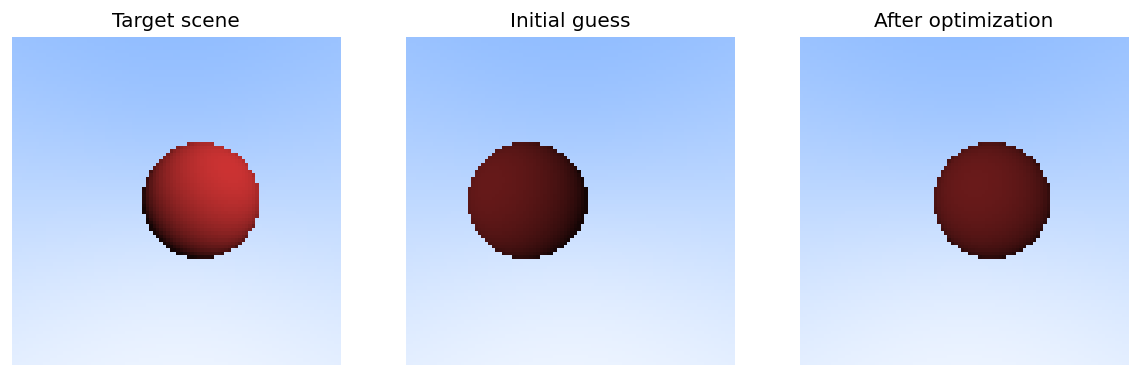

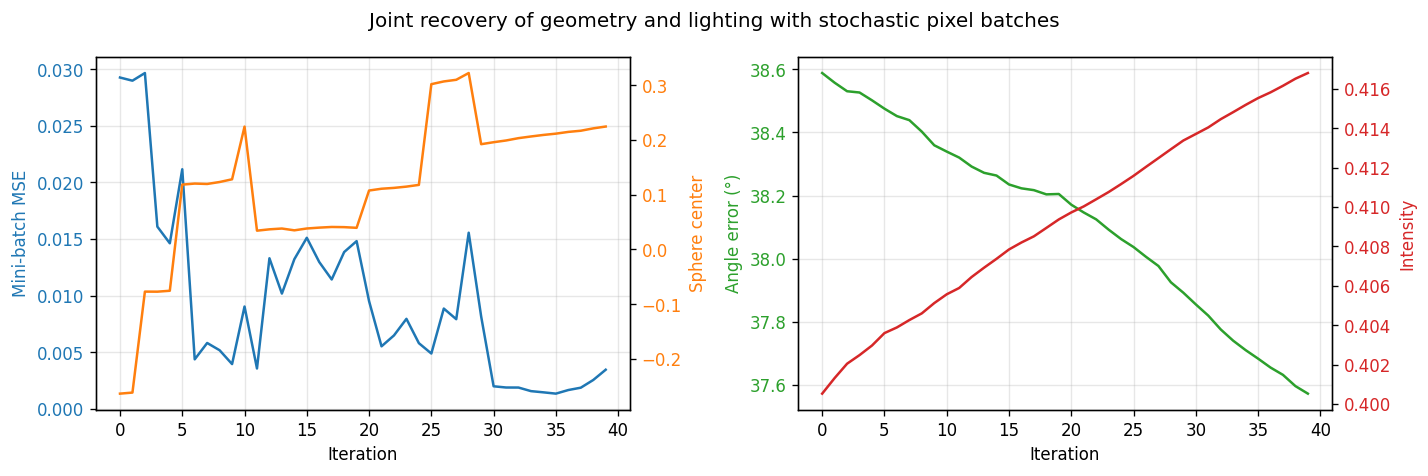

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(target_image)
axes[0].set_title('Target scene')
axes[1].imshow(initial_image)
axes[1].set_title('Initial guess')
axes[2].imshow(final_image)
axes[2].set_title('After optimization')
for ax in axes:
    ax.axis('off')
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(loss_hist, label='Stochastic loss', color='tab:blue')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Mini-batch MSE', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)
ax1_t = ax1.twinx()
ax1_t.plot(center_hist, label='Center x', color='tab:orange')
ax1_t.set_ylabel('Sphere center', color='tab:orange')
ax1_t.tick_params(axis='y', labelcolor='tab:orange')

ax2.plot(angle_hist, label='Direction error (deg)', color='tab:green')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Angle error (°)', color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')
ax2.grid(True, alpha=0.3)
ax2_t = ax2.twinx()
ax2_t.plot(intensity_hist, label='Light intensity', color='tab:red')
ax2_t.set_ylabel('Intensity', color='tab:red')
ax2_t.tick_params(axis='y', labelcolor='tab:red')
fig.suptitle('Joint recovery of geometry and lighting with stochastic pixel batches')
fig.tight_layout()
plt.show()

## Section C — Embedding the Renderer in a Tiny Neural Network
We now let a simple neural network predict the sphere center from image-level features.
Gradients still flow through the renderer via finite differences, but the chain rule connects them
to the network weights, mirroring how neural inverse-rendering systems are trained.

In [9]:
def image_features(image: np.ndarray) -> np.ndarray:
    h, w, _ = image.shape
    ys = np.linspace(1.0, -1.0, h)
    xs = np.linspace(-1.0, 1.0, w)
    grid_x, grid_y = np.meshgrid(xs, ys)
    brightness = image.mean(axis=2)
    mass = brightness / (brightness.sum() + 1e-8)
    x_com = np.sum(grid_x * mass)
    y_com = np.sum(grid_y * mass)
    color_mean = image.mean(axis=(0, 1))
    return np.concatenate([np.array([x_com, y_com]), color_mean, np.array([1.0])])

class TinyNet:
    def __init__(self, in_dim: int, hidden_dim: int = 8, seed: int = 0):
        rng = np.random.default_rng(seed)
        self.W1 = rng.normal(scale=0.3, size=(hidden_dim, in_dim))
        self.b1 = np.zeros(hidden_dim)
        self.W2 = rng.normal(scale=0.3, size=(1, hidden_dim))
        self.b2 = np.zeros(1)

    def forward(self, x: np.ndarray) -> float:
        self.x = x
        self.z1 = self.W1 @ x + self.b1
        self.h = np.tanh(self.z1)
        self.z2 = self.W2 @ self.h + self.b2
        return float(self.z2.item())

    def backward(self, grad_output: float):
        grad_z2 = grad_output
        grad_W2 = grad_z2 * self.h.reshape(1, -1)
        grad_b2 = np.array([grad_z2])
        grad_h = self.W2.T.flatten() * grad_z2
        grad_z1 = grad_h * (1.0 - self.h ** 2)
        grad_W1 = grad_z1[:, None] * self.x[None, :]
        grad_b1 = grad_z1
        return grad_W1, grad_b1, grad_W2, grad_b2

    def apply_updates(self, grads, lr: float):
        grad_W1, grad_b1, grad_W2, grad_b2 = grads
        self.W1 -= lr * grad_W1
        self.b1 -= lr * grad_b1
        self.W2 -= lr * grad_W2
        self.b2 -= lr * grad_b2

def finite_difference_center_full(center_x: float, light_params: np.ndarray, camera: Camera, target: np.ndarray, eps: float = 1e-3) -> float:
    loss_plus = mse(render_image(center_x + eps, light_params, camera), target)
    loss_minus = mse(render_image(center_x - eps, light_params, camera), target)
    return (loss_plus - loss_minus) / (2 * eps)


In [15]:
features = image_features(target_image)
net = TinyNet(len(features), hidden_dim=8, seed=7)

initial_center_nn = net.forward(features)
initial_image_nn = render_image(initial_center_nn, true_light_params, camera)

nn_lr = 0.08
nn_steps = 80
nn_loss_hist = []
nn_center_hist = []

for _ in range(nn_steps):
    pred_center = net.forward(features)
    loss = mse(render_image(pred_center, true_light_params, camera), target_image)
    grad_center = finite_difference_center_full(pred_center, true_light_params, camera, target_image)
    grads = net.backward(grad_center)
    net.apply_updates(grads, nn_lr)
    nn_loss_hist.append(loss)
    nn_center_hist.append(pred_center)

final_center_nn = net.forward(features)
final_image_nn = render_image(final_center_nn, true_light_params, camera)
print(f'Network-predicted center ≈ {final_center_nn:.3f} (target {true_center})')

Network-predicted center ≈ 0.200 (target 0.2)


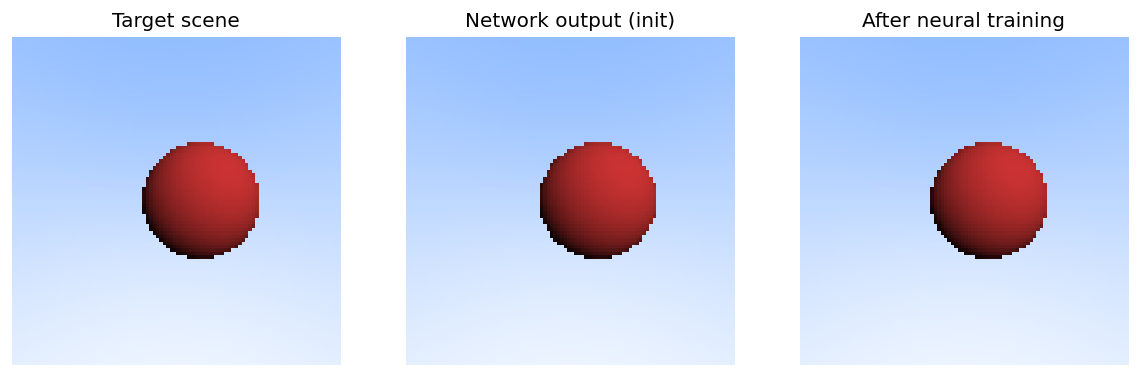

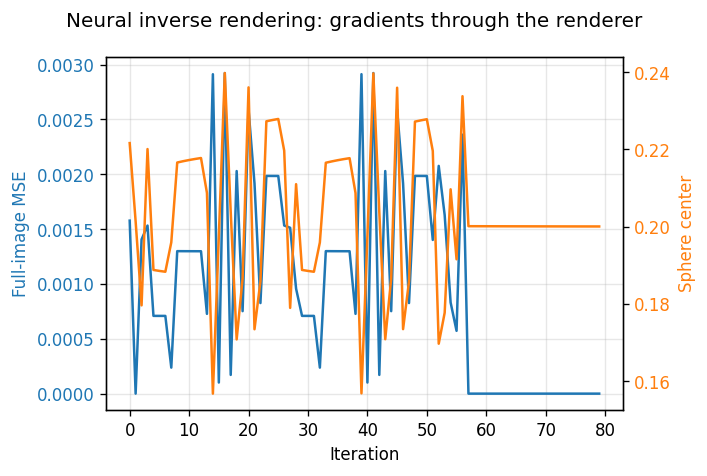

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(target_image)
axes[0].set_title('Target scene')
axes[1].imshow(initial_image_nn)
axes[1].set_title('Network output (init)')
axes[2].imshow(final_image_nn)
axes[2].set_title('After neural training')
for ax in axes:
    ax.axis('off')
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(nn_loss_hist, color='tab:blue', label='Loss')
ax.set_xlabel('Iteration')
ax.set_ylabel('Full-image MSE', color='tab:blue')
ax.tick_params(axis='y', labelcolor='tab:blue')
ax.grid(True, alpha=0.3)
ax_t = ax.twinx()
ax_t.plot(nn_center_hist, color='tab:orange', label='Center estimate')
ax_t.set_ylabel('Sphere center', color='tab:orange')
ax_t.tick_params(axis='y', labelcolor='tab:orange')
fig.suptitle('Neural inverse rendering: gradients through the renderer')
fig.tight_layout()
plt.show()

## Takeaways
- Lighting parameters can be optimized alongside geometry with simple finite differences.
- Sampling random pixels per iteration reduces rendering cost and mimics differentiable renderers that operate on stochastic batches.
- A lightweight neural network can be trained end-to-end when the renderer provides gradients (even numerically), illustrating the mechanics behind inverse rendering pipelines.
- To expand this notebook: fit multiple lights, add BRDF parameters, or train on a small dataset of synthetic images to learn priors over scenes.